## Regressão Logística

Dado um conjunto de observações

$$
V = \{(\vec{x_{i}}, y_i)\}_{i=1}^n
$$

onde

$$
\vec{x_i} =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R^{d}} \quad
  y_i \in \{0, 1\}
$$

vamos construir a matriz $X$ do seguinte modo:
    
$$
  X =
  \begin{bmatrix}
  1 & x_{11} & x_{12} & \cdots & x_{1p} \\
  1 & x_{21} & x_{22} & \cdots & x_{2p} \\
  \vdots & \vdots & \vdots & \ddots & \vdots \\
  1 & x_{n1} & x_{n2} & \cdots & x_{np}
  \end{bmatrix} \in \mathbb{R}^{n \times (d + 1)}
$$

Sabemos que $y_{i} \sim \mathbb{B}(p_{i})$ onde $p_i$ é dada por:

$$
p_i = \mathbb{P}[y_i = 1 | \vec{x}_i] = \sigma(x_i^{\top}\beta)
$$

onde

$$
\sigma(x_i^{\top}\beta) = \frac{1}{1 + e^{-(x_i^{\top}\beta)}}
$$

Assumindo a independência de $y_i$ em relação a $X$, vamos ainda definir a função de verossimilhança como:

$$
\mathbb{L}(\beta) := \prod_{i=1}^{n} p_i^{y_i}(1 - p_i)^{(1 - y_i)}
$$

Substituindo $p_i$ por $\sigma(x_i^{\top}\beta)$ temos que:

$$
\mathbb{L}(\beta) := \prod_{i=1}^{n} [\sigma(x_i^{\top}\beta)]^{y_i}[(1 - \sigma(x_i^{\top}\beta)]^{(1 - y_i)}
$$

Fazendo $\mathbb{l}(\beta) = \log \mathbb{L}(\beta)$, segue que

$$
\mathbb{l}(\beta) = \sum_{i=1}^{n} y_i\log \sigma(x_i^{\top}\beta) + (1 - y_i)\log (1 - \sigma(x_i^{\top}\beta))
$$

Por fim, dado que queremos determinar o vetor $\beta$, calculando $\nabla \mathbb{l}(\beta)$ temos:

$$
\nabla \mathbb{l}(\beta) = X^{\top}(y - p)
$$

Sendo a matriz Hessiana dada por:

$$
\mathbb{H}[\beta] = -X^{\top}WX
$$

onde:

$$
W = \text{diag}(p_i(1 - p_i))
$$

Por fim, segue que:

$$
\beta^{(t+1)} = \beta^{(t)} -\mathbb{H}^{-1}\nabla \mathbb{l}(\beta)
$$

ou seja:

$$
\beta^{(t+1)} = \beta^{(t)} + (X^{\top}WX)^{-1}X^{\top}(y - p)
$$


## Aplicação Básica de Regressão Logística

In [2]:
import numpy as np

data = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

X1 = data[:, 0]
X2 = data[:, 1]
Y  = data[:, 2]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient(X, y, beta):
    p = sigmoid(X @ beta)
    return X.T @ (y - p)

def hessian(X, beta):
    p = sigmoid(X @ beta)
    W = np.diag(p * (1 - p))
    return - X.T @ W @ X


In [3]:
def logistic_regression_irls(X, y, max_iter=100, tol=1e-6):
    n, d = X.shape
    beta = np.zeros(d)

    for i in range(max_iter):
        grad = gradient(X, y, beta)
        H = hessian(X, beta)

        delta = np.linalg.solve(H, grad)
        beta_new = beta - delta

        if np.linalg.norm(beta_new - beta) < tol:
            beta = beta_new
            break

        beta = beta_new

    return beta

In [4]:
X = np.column_stack((np.ones(len(X1)), X1, X2))

beta = logistic_regression_irls(X, Y)

print(beta)

[-16.1602695    1.74538164   1.48650834]


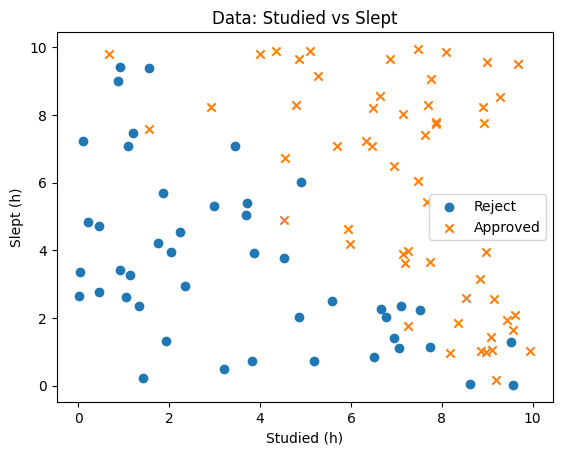

In [10]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(X1[Y==0], X2[Y==0], marker='o', label='Reject')
plt.scatter(X1[Y==1], X2[Y==1], marker='x', label='Approved')

plt.xlabel('Studied (h)')
plt.ylabel('Slept (h)')
plt.legend()
plt.title('Data: Studied vs Slept')
plt.show()


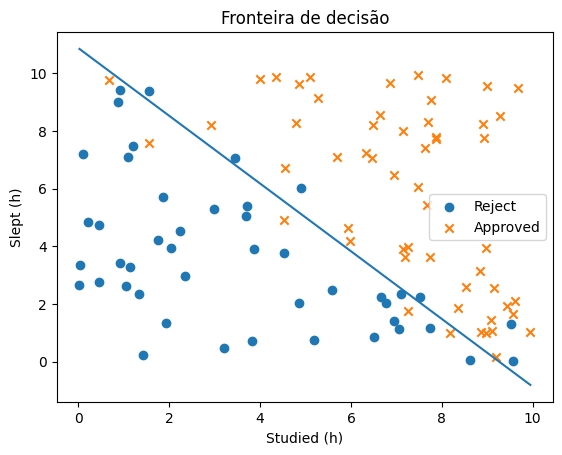

In [12]:
x1_vals = np.linspace(X1.min(), X1.max(), 100)
x2_vals = -(beta[0] + beta[1]*x1_vals) / beta[2]

plt.figure()

plt.scatter(X1[Y==0], X2[Y==0], marker='o', label='Reject')
plt.scatter(X1[Y==1], X2[Y==1], marker='x', label='Approved')

plt.plot(x1_vals, x2_vals)
plt.xlabel('Studied (h)')
plt.ylabel('Slept (h)')
plt.legend()
plt.title('Fronteira de decisão')
plt.show()
